In [2]:
#14-1-2026
#graupel prediction
#Mass-weighted random sampling
# start_time = 1979-01-12T00:00:00 
# end_time = 1979-01-12T00:00:00 

import time
overall_start_time = time.time()
import os
import sys

import numpy as np
import pandas as pd
#%matplotlib inline  #won't work for .py
import matplotlib.pyplot as plt
import xarray as xr

# import json_file_editer as JFE
from File_management import json_file_editer as JFE
from Calculation import job_manager 
from Tools import dataset_init
from Log_management import Log

import xgboost as xgb
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score

#random forest
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')

#ISLP
from matplotlib.pyplot import subplots
from statsmodels.datasets import get_rdataset
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from ISLP.models import ModelSpec as MS

from sklearn.tree import (DecisionTreeClassifier as DTC,
 DecisionTreeRegressor as DTR,
 plot_tree,
 export_text)
from sklearn.metrics import (accuracy_score,
 log_loss)
from sklearn.ensemble import \
 (RandomForestRegressor as RF,
 GradientBoostingRegressor as GBR)
from ISLP.bart import BART

#################################################################
Log.init_log(os.path.join('./output'), filename=f"Log_ML.txt")
Log.add_to_log("Log nicely initialized ")

options_json=JFE.get_json_data("options.json")
options_json["Header"]["status"]
chunks = {}
myJob = job_manager.JobManager(options_json)
ds = dataset_init.ds_init_3d(myJob, chunks={}) 

The job folder path : ./output/Log_ML.txt
2026 Jan 15 11:16:24 > Log nicely initialized 
2026 Jan 15 11:16:24 > (DI0010) making data from P-O files requires small differences in the code, hardly automisable.
2026 Jan 15 11:16:24 > (DI0020) Starting PO dataset creation from /work/mh0066/m301130/projects/scheme_comparison/icon-mpim/build/experiments/pod0001
2026 Jan 15 11:16:24 > (DI0021) Found 8 time-varying files in date range
2026 Jan 15 11:16:24 > (DI0022) Loading vertical grid data from /work/mh0066/m301130/projects/scheme_comparison/icon-mpim/build/experiments/pod0001/pod0001_atm_vgrid_ml.nc
2026 Jan 15 11:16:24 > (DI0023) Grid variables available: ['clon_bnds', 'clat_bnds', 'height_bnds', 'height_2_bnds', 'zghalf', 'zg', 'dzghalf', 'clon', 'clat', 'height', 'height_2']
2026 Jan 15 11:16:24 > (DI0024) Dimensions in vgrid: FrozenMappingWarningOnValuesAccess({'ncells': 20971520, 'vertices': 3, 'height': 60, 'bnds': 2, 'height_2': 60})
2026 Jan 15 11:16:24 > (DI0037) Loading horizonta

In [3]:
ds['hus']

<xarray.DataArray 'hus' (time: 1, height: 61, ncells: 20971520)> Size: 5GB
dask.array<where, shape=(1, 61, 20971520), dtype=float32, chunksize=(1, 1, 3497984), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 8B 1979-01-12
  * height   (height) float64 488B 2.0 31.0 32.0 33.0 ... 87.0 88.0 89.0 90.0
    clon     (ncells) float64 168MB dask.array<chunksize=(20971520,), meta=np.ndarray>
    clat     (ncells) float64 168MB dask.array<chunksize=(20971520,), meta=np.ndarray>
Dimensions without coordinates: ncells
Attributes:
    standard_name:                specific_humidity
    long_name:                    Specific humidity
    units:                        kg kg-1
    param:                        0.1.0
    CDI_grid_type:                unstructured
    number_of_grid_in_reference:  1

In [4]:
#RH from SH
def RH_from_SH(pfull, hus, ta, T_0= 273.16):
    RH = 0.26 * pfull * hus / np.exp(17.67 * (ta - T_0) / (ta - 29.65))
    return RH

In [5]:
# seed = 1
# # sample_frac = 0.001

# ht=88
# data=ds.sel(height=ht, height_2=ht) 

# total = data['clw'] + data['cli']
# data['clw/(clw+cli)'] = data['clw'].where(total != 0, 0) / total.where(total != 0, 1)
# data['cli/(clw+cli)'] = data['cli'].where(total != 0, 0) / total.where(total != 0, 1)

# total_precipitates = data['qr'] + data['qs']+ data['qg']
# data['qr/(qr+qs+qg)'] = data['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
# data['qs/(qr+qs+qg)'] = data['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
# data['qg/(qr+qs+qg)'] = data['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)

# df = data.to_dataframe() # df = data.to_dataframe() #.sample(frac=1, random_state=seed) #frac=sample_frac

In [6]:
# #uncomment this later

# dfs = [df]  
# # for ht in range(32, 91, 5): #(32, 91, 5)
# for ht in range(89, 91, 1): #(32, 91, 5)
#     print('You are at height = ', ht)
#     data = ds.sel(height=ht, height_2=ht)

#     total = data['clw'] + data['cli']
#     data['clw/(clw+cli)'] = data['clw'].where(total != 0, 0) / total.where(total != 0, 1)
#     data['cli/(clw+cli)'] = data['cli'].where(total != 0, 0) / total.where(total != 0, 1)

#     total_precipitates = data['qr'] + data['qs']+ data['qg']
#     data['qr/(qr+qs+qg)'] = data['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
#     data['qs/(qr+qs+qg)'] = data['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
#     data['qg/(qr+qs+qg)'] = data['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)

#     df_sampled=data.to_dataframe() #.sample(frac=1, random_state= seed+ht) #frac=sample_frac
#     dfs.append(df_sampled) 
#     # print(f"Last value of clon in df with height {ht} is", df_sampled['clon'].iloc[-1])

# df = pd.concat(dfs, ignore_index=True)

# # print('length of dfs: ',len(dfs))
# # print('len of dfs[0]: ', len(dfs[0]))
# prod= len(dfs[0]) * len(dfs)
# print("Expected length of df: ", prod)
# print('Final length of df: ', len(df))


In [7]:
# #The following code gives three copies of the same data cell

# # Define the height range you want
# height_range = [88, 89, 90]

# # Select only the heights you need from the dataset
# ds_subset = ds.sel(height=height_range, height_2=height_range)

# # ============================================
# # EXTRACT HUS VALUES FROM ABOVE AND BELOW
# # ============================================

# # Get hus values shifted by one height level
# # shift(height=1) moves values DOWN (cell above gets value from cell below)
# # shift(height=-1) moves values UP (cell below gets value from cell above)
# hus_above = ds_subset['hus'].shift(height=1)  # Value from height level above
# hus_below = ds_subset['hus'].shift(height=-1)  # Value from height level below

# # Handle boundary conditions:
# # For top level (88), use current cell's hus for hus_above
# # For bottom level (90), use current cell's hus for hus_below
# hus_above = hus_above.fillna(ds_subset['hus'])
# hus_below = hus_below.fillna(ds_subset['hus'])

# # Add these as new variables to the dataset
# ds_subset['hus_above'] = hus_above
# ds_subset['hus_below'] = hus_below

# # ============================================
# # CREATE YOUR DERIVED VARIABLES
# # ============================================

# # Calculate derived ratios (same as your original code)
# total = ds_subset['clw'] + ds_subset['cli']
# ds_subset['clw/(clw+cli)'] = ds_subset['clw'].where(total != 0, 0) / total.where(total != 0, 1)
# ds_subset['cli/(clw+cli)'] = ds_subset['cli'].where(total != 0, 0) / total.where(total != 0, 1)

# total_precipitates = ds_subset['qr'] + ds_subset['qs'] + ds_subset['qg']
# ds_subset['qr/(qr+qs+qg)'] = ds_subset['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
# ds_subset['qs/(qr+qs+qg)'] = ds_subset['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
# ds_subset['qg/(qr+qs+qg)'] = ds_subset['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)

# # ============================================
# # CONVERT TO DATAFRAME
# # ============================================

# # Convert the entire dataset to a dataframe in one operation
# df = ds_subset.to_dataframe().reset_index()

# print(f"Final dataframe shape: {df.shape}")
# print(f"Columns: {df.columns.tolist()}")

# # Verify hus_above and hus_below columns exist
# print("\nSample of hus values:")
# print(df[['height', 'clat', 'clon', 'hus', 'hus_above', 'hus_below']].head(15))

# # Check for any NaN values
# print(f"\nNaN count in hus_above: {df['hus_above'].isna().sum()}")
# print(f"NaN count in hus_below: {df['hus_below'].isna().sum()}")

In [8]:
# height_range = [88, 89, 90]

# #Create a list to store datasets for each height level
# ds_list = []

# for ht in height_range:
#     #Select where BOTH height and height_2 equal the same value
#     ds_ht = ds.sel(height=ht, height_2=ht)
#     ds_list.append(ds_ht)

# #Concatenate along the height dimension
# ds_subset = xr.concat(ds_list, dim='height')

# #EXTRACT HUS VALUES FROM ABOVE AND BELOW

# #Get hus values shifted by one height level
# hus_above = ds_subset['hus'].shift(height=1)
# hus_below = ds_subset['hus'].shift(height=-1)

# #Handle boundary conditions
# hus_above = hus_above.fillna(ds_subset['hus'])
# hus_below = hus_below.fillna(ds_subset['hus'])

# #Add to dataset
# ds_subset['hus_above'] = hus_above
# ds_subset['hus_below'] = hus_below

# #CALCULATE DERIVED RATIOS

# total = ds_subset['clw'] + ds_subset['cli']
# ds_subset['clw/(clw+cli)'] = ds_subset['clw'].where(total != 0, 0) / total.where(total != 0, 1)
# ds_subset['cli/(clw+cli)'] = ds_subset['cli'].where(total != 0, 0) / total.where(total != 0, 1)

# total_precipitates = ds_subset['qr'] + ds_subset['qs'] + ds_subset['qg']
# ds_subset['qr/(qr+qs+qg)'] = ds_subset['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
# ds_subset['qs/(qr+qs+qg)'] = ds_subset['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
# ds_subset['qg/(qr+qs+qg)'] = ds_subset['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)


# #CONVERT TO DATAFRAME

# df = ds_subset.to_dataframe().reset_index()

# print(f"Final dataframe shape: {df.shape}")
# print(f"Expected rows (if no missing data): {len(height_range) * ds['ncells'].size}")

# #Verify height == height_2 for all rows
# print(f"\nRows where height != height_2: {(df['height'] != df['height_2']).sum()}")

# print("\nSample of hus values:")
# print(df[['height', 'height_2', 'clat', 'clon', 'hus', 'hus_above', 'hus_below']].head(15))

# #Check for duplicates
# duplicates = df.duplicated(subset=['clat', 'clon', 'height']).sum()
# print(f"\nNumber of duplicate (clat, clon, height) combinations: {duplicates}")

# #Check for NaN values in hus (not hus_above/below)
# print(f"\nNaN count in original hus: {df['hus'].isna().sum()}")
# print(f"NaN count in hus_above: {df['hus_above'].isna().sum()}")
# print(f"NaN count in hus_below: {df['hus_below'].isna().sum()}")

In [5]:
#Above and below values for hus, pfull and ta

height_range = [88, 89, 90]

#Create a list to store datasets for each height level
ds_list = []

for ht in height_range:
    #Select where BOTH height and height_2 equal the same value
    ds_ht = ds.sel(height=ht, height_2=ht)
    ds_list.append(ds_ht)

#Concatenate along the height dimension
ds_subset = xr.concat(ds_list, dim='height')

#EXTRACT HUS VALUES FROM ABOVE AND BELOW

#Get hus values shifted by one height level
hus_above = ds_subset['hus'].shift(height=1)
hus_below = ds_subset['hus'].shift(height=-1)

#Handle boundary conditions
hus_above = hus_above.fillna(ds_subset['hus'])
hus_below = hus_below.fillna(ds_subset['hus'])

#Add to dataset
ds_subset['hus_above'] = hus_above
ds_subset['hus_below'] = hus_below

#EXTRACT ta VALUES FROM ABOVE AND BELOW

#Get ta values shifted by one height level
ta_above = ds_subset['ta'].shift(height=1)
ta_below = ds_subset['ta'].shift(height=-1)

#Handle boundary conditions
ta_above = ta_above.fillna(ds_subset['ta'])
ta_below = ta_below.fillna(ds_subset['ta'])

#Add to dataset
ds_subset['ta_above'] = ta_above
ds_subset['ta_below'] = ta_below

#EXTRACT pfull VALUES FROM ABOVE AND BELOW

#Get pfull values shifted by one height level
pfull_above = ds_subset['pfull'].shift(height=1)
pfull_below = ds_subset['pfull'].shift(height=-1)

#Handle boundary conditions
pfull_above = pfull_above.fillna(ds_subset['pfull'])
pfull_below = pfull_below.fillna(ds_subset['pfull'])

#Add to dataset
ds_subset['pfull_above'] = pfull_above
ds_subset['pfull_below'] = pfull_below

#CALCULATE DERIVED RATIOS

total = ds_subset['clw'] + ds_subset['cli']
ds_subset['clw/(clw+cli)'] = ds_subset['clw'].where(total != 0, 0) / total.where(total != 0, 1)
ds_subset['cli/(clw+cli)'] = ds_subset['cli'].where(total != 0, 0) / total.where(total != 0, 1)

total_precipitates = ds_subset['qr'] + ds_subset['qs'] + ds_subset['qg']
ds_subset['qr/(qr+qs+qg)'] = ds_subset['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
ds_subset['qs/(qr+qs+qg)'] = ds_subset['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
ds_subset['qg/(qr+qs+qg)'] = ds_subset['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)



#CONVERT TO DATAFRAME

df = ds_subset.to_dataframe().reset_index()

print(f"Final dataframe shape: {df.shape}")
print(f"Expected rows (if no missing data): {len(height_range) * ds['ncells'].size}")

#Verify height == height_2 for all rows
print(f"\nRows where height != height_2: {(df['height'] != df['height_2']).sum()}")

print("\nSample of hus values:")
print(df[['height', 'height_2', 'clat', 'clon', 'hus', 'hus_above', 'hus_below']].head(15))

#Check for duplicates
duplicates = df.duplicated(subset=['clat', 'clon', 'height']).sum()
print(f"\nNumber of duplicate (clat, clon, height) combinations: {duplicates}")

#Check for NaN values in hus (not hus_above/below)
print(f"\nNaN count in original hus: {df['hus'].isna().sum()}")
print(f"NaN count in hus_above: {df['hus_above'].isna().sum()}")
print(f"NaN count in hus_below: {df['hus_below'].isna().sum()}")


Final dataframe shape: (62914560, 38)
Expected rows (if no missing data): 62914560

Rows where height != height_2: 0

Sample of hus values:
    height  height_2      clat      clon       hus  hus_above  hus_below
0     88.0      88.0  0.918163  1.274090  0.002687   0.002687   0.002692
1     88.0      88.0  0.918508  1.275076  0.002665   0.002665   0.002670
2     88.0      88.0  0.918508  1.273105  0.002673   0.002673   0.002683
3     88.0      88.0  0.917471  1.274090  0.002674   0.002674   0.002678
4     88.0      88.0  0.919545  1.274090  0.002738   0.002738   0.002742
5     88.0      88.0  0.919200  1.275076  0.002666   0.002666   0.002675
6     88.0      88.0  0.920237  1.274090  0.002752   0.002752   0.002757
7     88.0      88.0  0.919200  1.273104  0.002712   0.002712   0.002721
8     88.0      88.0  0.917470  1.272123  0.002681   0.002681   0.002684
9     88.0      88.0  0.918163  1.272121  0.002667   0.002667   0.002674
10    88.0      88.0  0.917124  1.271142  0.002700   0.00

In [6]:
df

,height,ncells,time,cell_area,pr,tas,clivi,cllvi,qgvi,qrvi,...,hus_below,ta_above,ta_below,pfull_above,pfull_below,clw/(clw+cli),cli/(clw+cli),qr/(qr+qs+qg),qs/(qr+qs+qg),qg/(qr+qs+qg)
0,88.0,0,1979-01-12,2.517519e+07,1.693205e-05,NaN,1.956515e-02,0.002318,6.807788e-03,1.365215e-12,...,0.002692,269.496613,270.089630,97769.085938,98567.132812,0.000000e+00,1.000000,0.0,0.814222,0.185778
1,88.0,1,1979-01-12,2.518261e+07,1.406137e-05,NaN,1.598972e-02,0.000863,5.338005e-03,7.608922e-13,...,0.002670,269.799957,270.385620,97982.710938,98784.523438,3.531526e-23,1.000000,0.0,0.847542,0.152458
2,88.0,2,1979-01-12,2.518261e+07,2.459891e-05,NaN,1.454868e-02,0.001344,7.660680e-03,1.084701e-06,...,0.002683,269.636597,270.187134,97697.656250,98493.625000,4.210584e-05,0.999958,0.0,0.805670,0.194330
3,88.0,3,1979-01-12,2.518266e+07,8.591708e-06,NaN,2.683672e-02,0.001184,6.412509e-03,3.005283e-06,...,0.002678,269.414490,270.005890,97674.976562,98471.117188,3.680544e-06,0.999996,0.0,0.770084,0.229916
4,88.0,4,1979-01-12,2.518255e+07,2.625065e-05,NaN,1.094598e-02,0.000003,6.387512e-03,4.762747e-13,...,0.002742,269.438446,270.035370,97882.750000,98682.992188,0.000000e+00,1.000000,0.0,0.813137,0.186863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62914555,90.0,20971515,1979-01-12,2.508243e+07,2.324111e-16,NaN,1.497422e-08,0.000001,3.693715e-07,2.148169e-11,...,0.004334,278.950745,279.532135,100524.140625,101013.093750,0.000000e+00,1.000000,0.0,0.972731,0.027269
62914556,90.0,20971516,1979-01-12,2.507718e+07,-5.120155e-12,NaN,2.848138e-06,0.088135,2.754859e-04,9.408985e-05,...,0.004907,279.015137,279.564117,100490.718750,100979.242188,9.999982e-01,0.000002,0.0,0.040300,0.959700
62914557,90.0,20971517,1979-01-12,2.508338e+07,-4.616800e-11,NaN,1.036285e-06,0.046316,3.683916e-04,1.619615e-04,...,0.004756,278.968597,279.533112,100501.007812,100989.703125,9.999970e-01,0.000003,0.0,0.015393,0.984607
62914558,90.0,20971518,1979-01-12,2.508432e+07,-4.219087e-10,NaN,2.515754e-06,0.066022,1.175604e-05,3.137170e-06,...,0.004939,278.943848,279.494232,100484.695312,100973.296875,9.999972e-01,0.000003,0.0,0.617652,0.382348


In [11]:
# df88 = df.query("height == 88")[["clat", "clon", "hus"]].rename(columns={"hus": "hus_88"})
# df89 = df.query("height == 89")[["clat", "clon", "hus", "hus_above", "hus_below"]]
# df90 = df.query("height == 90")[["clat", "clon", "hus"]].rename(columns={"hus": "hus_90"})

# check = (
#     df89
#     .merge(df88, on=["clat", "clon"], how="left")
#     .merge(df90, on=["clat", "clon"], how="left")
# )

# print((check["hus_above"] - check["hus_88"]).abs().max())
# print((check["hus_below"] - check["hus_90"]).abs().max())

In [7]:
if (
    (ds_subset.sel(height=89)["hus_above"] == ds_subset.sel(height=88)["hus"]).all() and
    (ds_subset.sel(height=89)["hus_below"] == ds_subset.sel(height=90)["hus"]).all()
):
    print("All assertions passed for hus!")

if (
    (ds_subset.sel(height=89)["ta_above"] == ds_subset.sel(height=88)["ta"]).all() and
    (ds_subset.sel(height=89)["ta_below"] == ds_subset.sel(height=90)["ta"]).all()
):
    print("All assertions passed for ta!")

if (
    (ds_subset.sel(height=89)["pfull_above"] == ds_subset.sel(height=88)["pfull"]).all() and
    (ds_subset.sel(height=89)["pfull_below"] == ds_subset.sel(height=90)["pfull"]).all()
):
    print("All assertions passed for pfull!")

All assertions passed for hus!
All assertions passed for ta!
All assertions passed for pfull!


In [13]:
# # SANITY CHECK: Visual verification


# print("=" * 80)
# print("SANITY CHECK: Verifying hus_above and hus_below alignment")
# print("=" * 80)

# # Select a few random (clat, clon) locations to inspect
# unique_locations = df[['clat', 'clon']].drop_duplicates().sample(n=5, random_state=42)

# for idx, loc in unique_locations.iterrows():
#     lat, lon = loc['clat'], loc['clon']
    
#     # Get all rows for this location, sorted by height
#     location_data = df[(df['clat'] == lat) & (df['clon'] == lon)].sort_values('height').reset_index(drop=True)
    
#     print(f"\n{'='*80}")
#     print(f"Location: clat={lat:.6f}, clon={lon:.6f}")
#     print(f"{'='*80}")
#     print(location_data[['height', 'hus', 'hus_above', 'hus_below']].to_string(index=False))
    
#     # Manual verification with arrows showing relationships
#     print("\nVerification:")
#     for i, row in location_data.iterrows():
#         h = row['height']
#         hus = row['hus']
#         hus_above = row['hus_above']
#         hus_below = row['hus_below']
        
#         # Check hus_above
#         if h == 88:  # Top boundary
#             expected_above = hus
#             status_above = "✓" if np.isclose(hus_above, expected_above) else "✗"
#             print(f"  Height {int(h)}: hus_above={hus_above:.6f} (boundary, expects self={expected_above:.6f}) {status_above}")
#         else:
#             prev_row = location_data[location_data['height'] == h - 1]
#             if not prev_row.empty:
#                 expected_above = prev_row['hus'].values[0]
#                 status_above = "✓" if np.isclose(hus_above, expected_above) else "✗"
#                 print(f"  Height {int(h)}: hus_above={hus_above:.6f} (expects hus from h={int(h-1)}: {expected_above:.6f}) {status_above}")
        
#         # Check hus_below
#         if h == 90:  # Bottom boundary
#             expected_below = hus
#             status_below = "✓" if np.isclose(hus_below, expected_below) else "✗"
#             print(f"  Height {int(h)}: hus_below={hus_below:.6f} (boundary, expects self={expected_below:.6f}) {status_below}")
#         else:
#             next_row = location_data[location_data['height'] == h + 1]
#             if not next_row.empty:
#                 expected_below = next_row['hus'].values[0]
#                 status_below = "✓" if np.isclose(hus_below, expected_below) else "✗"
#                 print(f"  Height {int(h)}: hus_below={hus_below:.6f} (expects hus from h={int(h+1)}: {expected_below:.6f}) {status_below}")

# # ============================================
# # COMPREHENSIVE CHECK: All locations
# # ============================================

# print("\n" + "=" * 80)
# print("COMPREHENSIVE CHECK: Testing all cells in dataframe")
# print("=" * 80)

# errors_above = 0
# errors_below = 0
# total_cells = 0

# for (lat, lon), group in df.groupby(['clat', 'clon']):
#     group_sorted = group.sort_values('height').reset_index(drop=True)
    
#     for idx, row in group_sorted.iterrows():
#         total_cells += 1
#         h = row['height']
        
#         # Check hus_above
#         if h == 88:  # Boundary
#             if not np.isclose(row['hus_above'], row['hus']):
#                 errors_above += 1
#         else:
#             if idx > 0:
#                 expected_above = group_sorted.iloc[idx - 1]['hus']
#                 if not np.isclose(row['hus_above'], expected_above):
#                     errors_above += 1
        
#         # Check hus_below
#         if h == 90:  # Boundary
#             if not np.isclose(row['hus_below'], row['hus']):
#                 errors_below += 1
#         else:
#             if idx < len(group_sorted) - 1:
#                 expected_below = group_sorted.iloc[idx + 1]['hus']
#                 if not np.isclose(row['hus_below'], expected_below):
#                     errors_below += 1

# print(f"Total cells checked: {total_cells:,}")
# print(f"Errors in hus_above: {errors_above}")
# print(f"Errors in hus_below: {errors_below}")

# if errors_above == 0 and errors_below == 0:
#     print("\n" + "🎉" * 40)
#     print("✅ PERFECT! All hus_above and hus_below values are correctly aligned!")
#     print("🎉" * 40)
# else:
#     print(f"\n❌ Found {errors_above + errors_below} errors")

# # ============================================
# # VISUAL TABLE: One location in detail
# # ============================================

# print("\n" + "=" * 80)
# print("DETAILED VIEW: One location with annotations")
# print("=" * 80)

# # Pick the first location for detailed view
# sample_location = df.groupby(['clat', 'clon']).first().iloc[0]
# sample_lat, sample_lon = sample_location.name

# sample_data = df[(df['clat'] == sample_lat) & (df['clon'] == sample_lon)].sort_values('height')

# print(f"\nLocation: clat={sample_lat:.6f}, clon={sample_lon:.6f}\n")
# print(f"{'Height':<8} {'hus':<12} {'hus_above':<12} {'hus_below':<12} {'Notes'}")
# print("-" * 80)

# for idx, row in sample_data.iterrows():
#     h = int(row['height'])
#     hus = row['hus']
#     hus_above = row['hus_above']
#     hus_below = row['hus_below']
    
#     if h == 88:
#         notes = "← hus_above = self (top boundary)"
#     elif h == 90:
#         notes = "← hus_below = self (bottom boundary)"
#     else:
#         notes = ""
    
#     print(f"{h:<8} {hus:<12.6f} {hus_above:<12.6f} {hus_below:<12.6f} {notes}")

# print("\nReading the table:")
# print("  • Row with height=88: hus_above should equal hus (boundary condition)")
# print("  • Row with height=89: hus_above should equal hus from height=88")
# print("  •                     hus_below should equal hus from height=90")
# print("  • Row with height=90: hus_below should equal hus (boundary condition)")

In [8]:
threshold = 5e-12
old_df_len = len(df)
print("Length of the old df: ", old_df_len)
df_new = df[(df['cli'] + df['clw'] + df['qr'] + df['qg'] + df['qs']) >= threshold]
# print('df- After threshold-1:')
# print(df_new)
if df_new.empty:
    df_new = df

df = df_new
new_df_len = len(df)
# print('df after threshold-2:\n', df)
print("Length of the new df: ", new_df_len)
print("Difference in the length of dataframes = ", (old_df_len - new_df_len))

Length of the old df:  62914560
Length of the new df:  25329001
Difference in the length of dataframes =  37585559


In [9]:
df['RH']=RH_from_SH(df['pfull'], df['hus'], df['ta'])
df['RH_above']=RH_from_SH(df['pfull_above'], df['hus_above'], df['ta_above'])
df['RH_below']=RH_from_SH(df['pfull_below'], df['hus_below'], df['ta_below'])

In [10]:
count=0
for i in df['RH']:
    if i>100 or i<0:
        count+=1
print("Out_of_range count = ", count)
print("Out_of_range count percent = ", 100*count/len(df['RH']))


df['RH']= df['RH'].clip(lower=0, upper=100)

count=0
for i in df['RH_above']:
    if i>100 or i<0:
        count+=1
print("Out_of_range count = ", count)
print("Out_of_range count percent = ", 100*count/len(df['RH_above']))


df['RH_above']= df['RH_above'].clip(lower=0, upper=100)

count=0
for i in df['RH_below']:
    if i>100 or i<0:
        count+=1
print("Out_of_range count = ", count)
print("Out_of_range count percent = ", 100*count/len(df['RH_below']))


df['RH_below']= df['RH_below'].clip(lower=0, upper=100)

Out_of_range count =  422147
Out_of_range count percent =  1.6666547567351748
Out_of_range count =  755302
Out_of_range count percent =  2.9819652184466334
Out_of_range count =  88536
Out_of_range count percent =  0.349543987147381


In [11]:
print(df.columns)

Index(['height', 'ncells', 'time', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi',
       'qgvi', 'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'hus', 'ta',
       'wa', 'rho', 'dzghalf', 'ua', 'va', 'pfull', 'clon', 'clat', 'height_2',
       'hus_above', 'hus_below', 'ta_above', 'ta_below', 'pfull_above',
       'pfull_below', 'clw/(clw+cli)', 'cli/(clw+cli)', 'qr/(qr+qs+qg)',
       'qs/(qr+qs+qg)', 'qg/(qr+qs+qg)', 'RH', 'RH_above', 'RH_below'],
      dtype='object')


In [12]:
col=df.pop('RH')
df.insert(17, 'RH', col) #hus is at 16th position
#df.pop('hus')

col=df.pop('RH_above')
df.insert(18, 'RH_above', col) 

col=df.pop('RH_below')
df.insert(19, 'RH_below', col) 

In [13]:
print(df.columns)

Index(['height', 'ncells', 'time', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi',
       'qgvi', 'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'hus', 'RH',
       'RH_above', 'RH_below', 'ta', 'wa', 'rho', 'dzghalf', 'ua', 'va',
       'pfull', 'clon', 'clat', 'height_2', 'hus_above', 'hus_below',
       'ta_above', 'ta_below', 'pfull_above', 'pfull_below', 'clw/(clw+cli)',
       'cli/(clw+cli)', 'qr/(qr+qs+qg)', 'qs/(qr+qs+qg)', 'qg/(qr+qs+qg)'],
      dtype='object')


In [14]:
df['clw+cli']=df['clw']+df['cli']

col=df.pop('clw+cli')
df.insert(36, 'clw+cli', col) 

In [15]:
#Include 'cloud liquid water path + cloud ice path' as a feature.

df['cllvi+clivi']=df['cllvi']+df['clivi']

col=df.pop('cllvi+clivi')
df.insert(37, 'cllvi+clivi', col) 

# df.to_csv("df.csv", index=False)

In [16]:
# m_ci_j=dzghalf*rho*cell_area*(clw+cli)

#NOte df['m_ci'] actually refers to mass of clw+cli+qr+qg+qs

df['m_ci']=df['dzghalf']*df['rho']*df['cell_area']* (df['clw']+df['cli'])

col=df.pop('m_ci')
df.insert(38, 'm_ci', col) 

In [17]:
df = df.sort_values(by='m_ci', ascending=False)

df = df.reset_index(drop=True)

total_mass = df['m_ci'].sum()

df['cum_mass'] = df['m_ci'].cumsum()

col=df.pop('cum_mass')
df.insert(39, 'cum_mass', col) 

In [18]:
#Adding another column; qr+qg+qs and use it later as an input feature

df['qr+qg+qs'] = df['qr'] + df['qg'] + df['qs']

col=df.pop('qr+qg+qs')
df.insert(40, 'qr+qg+qs', col)

In [27]:
# n_samples= int(np.floor(len(df) * 0.1)) #we are taking a way smaller dataset because of this 
# # n_samples= int(np.floor(len(df))) 
# # n_samples= int(np.floor(len(df))) 
# np.random.seed(29)

# random_values = np.random.uniform(0, total_mass, size=n_samples)

# print('Random values: ', random_values)

# indices= np.searchsorted(df['cum_mass'].values, random_values)

# df_orig=df

# df = df.iloc[indices].reset_index(drop=True)

In [28]:
# import seaborn as sns

# plt.figure(figsize=(8,6))
# sns.scatterplot(x=y_test.flatten(), y=y_predicted.flatten(), alpha=0.7)
# plt.xlabel("Actual Values")
# plt.ylabel("Predicted Values")
# plt.title("Actual vs Predicted Values (MLR)")
# # Add a perfect prediction line
# plt.plot([y_test.min(), y_test.max()],
#          [y_test.min(), y_test.max()],
#          color='red', lw=2)
# plt.show()


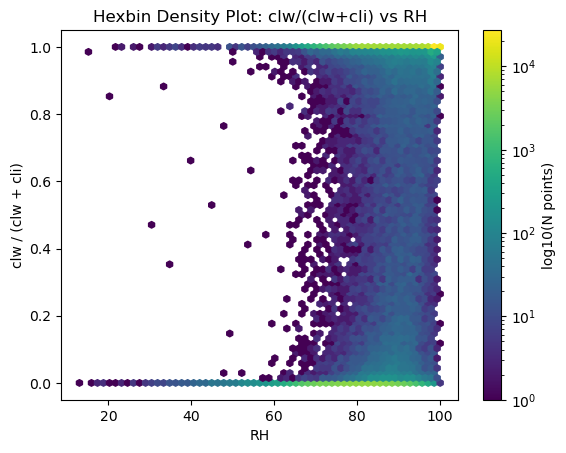

In [29]:
plt.hexbin(
    df['RH'][::100],
    df['clw/(clw+cli)'][::100],
    gridsize=60,    # adjust resolution (smaller = finer)
    cmap='viridis', # color map
    bins='log'      # use log scale for density
)
plt.colorbar(label='log10(N points)')
# plt.xlim(95, 100)
plt.xlabel("RH")
plt.ylabel("clw / (clw + cli)")
plt.title("Hexbin Density Plot: clw/(clw+cli) vs RH")
plt.show()


In [30]:
df.columns

Index(['height', 'ncells', 'time', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi',
       'qgvi', 'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'hus', 'RH',
       'RH_above', 'RH_below', 'ta', 'wa', 'rho', 'dzghalf', 'ua', 'va',
       'pfull', 'clon', 'clat', 'height_2', 'hus_above', 'hus_below',
       'ta_above', 'ta_below', 'pfull_above', 'pfull_below', 'clw+cli',
       'cllvi+clivi', 'm_ci', 'cum_mass', 'qr+qg+qs', 'clw/(clw+cli)',
       'cli/(clw+cli)', 'qr/(qr+qs+qg)', 'qs/(qr+qs+qg)', 'qg/(qr+qs+qg)'],
      dtype='object')

In [32]:
# # print(df.apply(tuple, axis=1).value_counts())
# # df.head(100).duplicated().sum()
# n_duplicates = df.duplicated().sum() #To know how many repeats exist

# print("Percentage of duplicates = ", n_duplicates * 100 / len(df))

In [33]:
# #To see the repeated rows
# # df.head(100)[df.head(100).duplicated(keep=False)]

# df[df.duplicated(keep=False)]


In [34]:
# import pandas as pd

# # Assuming your dataframe is called 'df' and has columns: 'clat', 'clon', 'height', 'RH'

# # Sort the dataframe by clat, clon, and height
# df = df.sort_values(['clat', 'clon', 'height']).reset_index(drop=True)

# # Create a mapping from (clat, clon, height) to RH value
# # This allows quick lookup of RH values at specific locations
# df['position_height_key'] = (df['clat'].astype(str) + '_' + 
#                               df['clon'].astype(str) + '_' + 
#                               df['height'].astype(str))
# rh_lookup = df.set_index('position_height_key')['RH'].to_dict()

# # Function to get RH at a specific location
# def get_rh_at_height(row, height_offset):
#     target_height = row['height'] + height_offset
#     key = f"{row['clat']}_{row['clon']}_{target_height}"
#     return rh_lookup.get(key, None)

# # Calculate RH_above (height - 1, since lower height number = higher altitude)
# df['RH_above'] = df.apply(
#     lambda row: row['RH'] if row['height'] == 81 else get_rh_at_height(row, -1),
#     axis=1
# )

# # Calculate RH_below (height + 1, since higher height number = lower altitude)
# df['RH_below'] = df.apply(
#     lambda row: row['RH'] if row['height'] == 90 else get_rh_at_height(row, 1),
#     axis=1
# )

# # Clean up helper column
# df = df.drop('position_height_key', axis=1)

# # Verify the results
# print("Sample of dataframe with new columns:")
# print(df[['clat', 'clon', 'height', 'RH', 'RH_above', 'RH_below']].head(20))

In [35]:
# import pandas as pd

# #Sort the dataframe by clat, clon, and height
# df = df.sort_values(['clat', 'clon', 'height']).reset_index(drop=True)

# # Create a mapping from (clat, clon, height) to RH value
# # This allows quick lookup of RH values at specific locations
# df['position_height_key'] = (df['clat'].astype(str) + '_' + 
#                               df['clon'].astype(str) + '_' + 
#                               df['height'].astype(str))
# rh_lookup = df.set_index('position_height_key')['RH'].to_dict()

# # Function to get RH at a specific location
# def get_rh_at_height(row, height_offset):
#     target_height = row['height'] + height_offset
#     key = f"{row['clat']}_{row['clon']}_{target_height}"
#     return rh_lookup.get(key, None)

# # Calculate RH_above (height - 1, since lower height number = higher altitude)
# df['RH_above'] = df.apply(
#     lambda row: row['RH'] if row['height'] == 81 else get_rh_at_height(row, -1),
#     axis=1
# )

# # Calculate RH_below (height + 1, since higher height number = lower altitude)
# df['RH_below'] = df.apply(
#     lambda row: row['RH'] if row['height'] == 90 else get_rh_at_height(row, 1),
#     axis=1
# )

# # Replace any NaN values in RH_above with the current cell's RH value
# df['RH_above'] = df['RH_above'].fillna(df['RH'])

# # Replace any NaN values in RH_below with the current cell's RH value
# df['RH_below'] = df['RH_below'].fillna(df['RH'])

# # Clean up helper column
# df = df.drop('position_height_key', axis=1)

# # Verify the results
# print("Sample of dataframe with new columns:")
# print(df[['clat', 'clon', 'height', 'RH', 'RH_above', 'RH_below']].head(20))

# # Check if there are any remaining NaN values
# print("\nNumber of NaN values:")
# print(f"RH_above: {df['RH_above'].isna().sum()}")
# print(f"RH_below: {df['RH_below'].isna().sum()}")

In [19]:
# print("Description of the df:\n")
# print(df[['cli', 'clw', 'qr', 'qg', 'qs']].describe())
# print(df[['cli', 'clw', 'qr', 'qg', 'qs']].isna().sum())
# print("Description ends\n")

# split data into X and y
# X = df.iloc[:, [15,16]].values # RH, ta
# X = df.iloc[:, [16,17,18,19,20,21,24,25,26,27,28,36,37,40]].values 
X = df.iloc[:, [16,17,18,19,20,21,24,25,26,27,28,36,37,40]].values 

y = df.iloc[:, [-1]].values 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

cols= [16,17,18,19,20,21,24,25,26,27,28,36,37,40]
feature_names=df.columns[cols].tolist()
print(feature_names)

['hus', 'RH', 'RH_above', 'RH_below', 'ta', 'wa', 'ua', 'va', 'pfull', 'clon', 'clat', 'clw+cli', 'cllvi+clivi', 'qr+qg+qs']


In [20]:
print(len(y_train))
print(len(y_test))

20263200
5065801


Decision Tree

In [ ]:
# # #Medium
# # #Use Cross-Validation
# # #best depth acc. to val data

# train_r2_scores=[]
# val_r2_scores=[]
# depths=range(1,11) #This seemed a reasonable depth range which is obtained from trial and error and articles online
# for depth in depths:
#     tree=DTR(max_depth=depth, random_state=1)
#     #train
#     tree.fit(X_train,y_train)
#     train_score=tree.score(X_train, y_train)
#     train_r2_scores.append(train_score)
#     # print(f"Depth {depth}: Training R2 score = {train_score} ") 

#     #val
    
#     val_scores= cross_val_score(tree, X_train, y_train, cv=5, scoring='r2')
#     # print(f"Depth {depth}: Mean Validation R2 score = {val_scores.mean()} ") #val_scores.mean(): .4f
#     val_r2_scores.append(val_scores.mean())

# #print(type(val_scores)) #<class 'numpy.ndarray'>
# #print(val_scores)
# max_val_r2_score=max(val_r2_scores)
# bestDepth=depths[val_r2_scores.index(max_val_r2_score)]
# print(f"\nMax. Validation R2 score: {max_val_r2_score} is at depth (bestDepth): {bestDepth}") #Validation R2 score is different from Test R2 score

# #Plotting
# plt.figure() #figsize=(8,5)
# plt.plot(depths, train_r2_scores, marker='o', label='Training R2')
# plt.plot(depths, val_r2_scores, marker='s', label='Validation R2')
# plt.xlabel("Tree Depth")
# plt.ylabel("R2 score")
# plt.title("Decision Tree Performance vs Depth")
# plt.legend()
# plt.grid(True)
# plt.show()

# #time taken = 64 mins 51 seconds

In [ ]:
# #to find the best Depth and the best number of min samples in leaf
# depths = range(1, 11) #range(1, 21)
# min_samples_in_leaf = range(1, 41) #range(1,51)

# train_r2_scores = []
# val_r2_scores = []
# param_combinations = []

# best_val_score = -np.inf
# best_depth = None
# best_min_samples_leaf = None

# for depth in depths:
#     for min_samples in min_samples_in_leaf:
#         tree = DTR(max_depth=depth, min_samples_leaf=min_samples, random_state=1)

#         tree.fit(X_train, y_train)
#         train_score = tree.score(X_train, y_train)
      
#         val_scores = cross_val_score(tree, X_train, y_train, cv=5, scoring='r2')
#         val_mean = val_scores.mean()
       
#         train_r2_scores.append(train_score)
#         val_r2_scores.append(val_mean)
#         param_combinations.append((depth, min_samples))

#         if val_mean > best_val_score:
#             best_val_score = val_mean
#             best_depth = depth
#             best_min_samples_leaf = min_samples

# print(f"\nBest Validation R2 Score: {best_val_score: }")
# print(f"Best Parameters: max_depth={best_depth}, min_samples_leaf={best_min_samples_leaf}")

# #took 48 mins to run
# #eg: max_depth=14, min_samples_leaf=40

In [ ]:
# #Plot

# param_combinations = np.array(param_combinations)
# depths_arr = param_combinations[:, 0]
# min_samples_arr = param_combinations[:, 1]
# val_r2_scores = np.array(val_r2_scores)


# plt.figure(figsize=(10, 6))
# plt.tricontourf(depths_arr, min_samples_arr, val_r2_scores, levels=20, cmap='viridis')
# plt.colorbar(label="Mean CV (Validation) R2 Score")
# plt.xlabel("Tree Depth")
# plt.ylabel("Min Samples in Leaf")
# plt.title("Decision Tree Cross-Validation Performance Grid Search")
# plt.show()


In [21]:
#Pathway-1
best_depth= 10 #14
best_min_samples_leaf=30 #40

reg=DTR(max_depth=best_depth, min_samples_leaf=best_min_samples_leaf, random_state=0)

##Training
training_start_time = time.time()
reg.fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

# ax=subplots(figsize=(12,12))[1]
# plot_tree(reg, feature_names=feature_names, ax=ax)

Training- Elapsed time: 11.4855 minutes


In [22]:
#Prediction
prediction_start_time = time.time()
y_pred = reg.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

Prediction- Elapsed time: 0.0072 minutes


In [23]:
y_test=y_test.ravel()
y_pred=y_pred.ravel()

#Error Analysis on TEST data
#MSE_test
mse_TEST= np.mean((y_test- y_pred)**2)
print(f'MSE_TEST: {mse_TEST}')

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
print(f'RMSE_TEST: {rmse_TEST}')
# print(f'MSE_TEST: {(rmse_TEST)**2}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_pred))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_pred)
print("R² score before CCP:", r2_sklearn)

MSE_TEST: 0.020188298911591233
RMSE_TEST: 0.14208553378719183
mae_TEST: 0.07774979566808003
R² score before CCP: 0.7751577533483773


In [ ]:
# #Pathway-1
# #This seems more robust because it uses CV and not test data to determine the best ccp_alpha

# ccp_path = reg.cost_complexity_pruning_path(X_train, y_train)

# kfold = skm.KFold(5,
# shuffle=True,
# random_state=10)

# grid = skm.GridSearchCV(reg,
# {'ccp_alpha': ccp_path.ccp_alphas},
# refit=True,
# cv=kfold,
# scoring='r2',
# n_jobs=-1)

# G = grid.fit(X_train, y_train)

# best_ = grid.best_estimator_
# print(best_)

# depth = best_.get_depth()
# print(depth)

In [ ]:
# #Pathway-1
# #Plot the best tree
# ax= subplots(figsize=(12,12))[1]
# plot_tree(G.best_estimator_, feature_names=feature_names, ax=ax) #after ccp

In [ ]:
# # ##Prediction
# prediction_start_time = time.time()
# y_pred = best_.predict(X_test)
# prediction_end_time = time.time()
# prediction_elapsed_time = prediction_end_time - prediction_start_time
# print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

# #########################################
# print('size of y_pred: ', len(y_pred))

In [ ]:
# #Comment this block if you do CCP

# ##Prediction
# prediction_start_time = time.time()
# y_pred = reg.predict(X_test)
# prediction_end_time = time.time()
# prediction_elapsed_time = prediction_end_time - prediction_start_time
# print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

# #########################################
# print('size of y_pred: ', len(y_pred))

In [ ]:
# #Error Analysis on TEST data
# #MSE_test
# mse_TEST= np.mean((y_test- y_pred)**2)
# print(f'MSE_TEST: {mse_TEST}')

# #rmse_test
# rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
# print(f'RMSE_TEST: {rmse_TEST}')
# # print(f'MSE_TEST: {(rmse_TEST)**2}')

# #mae_TEST
# mae_TEST = np.mean(abs(y_test - y_pred))
# print(f'mae_TEST: {mae_TEST}')

# #R2_test_sklearn
# r2_sklearn = r2_score(y_test, y_pred)
# print("R² score:", r2_sklearn)

hus:42.2261 %
qr+qg+qs:38.0258 %
cllvi+clivi:9.1754 %
ta:2.8318 %
RH_above:2.5967 %
clw+cli:2.2542 %
RH:1.5931 %
clon:0.4337 %
clat:0.3304 %
RH_below:0.2105 %
pfull:0.1505 %
ua:0.1309 %
va:0.0347 %
wa:0.0060 %


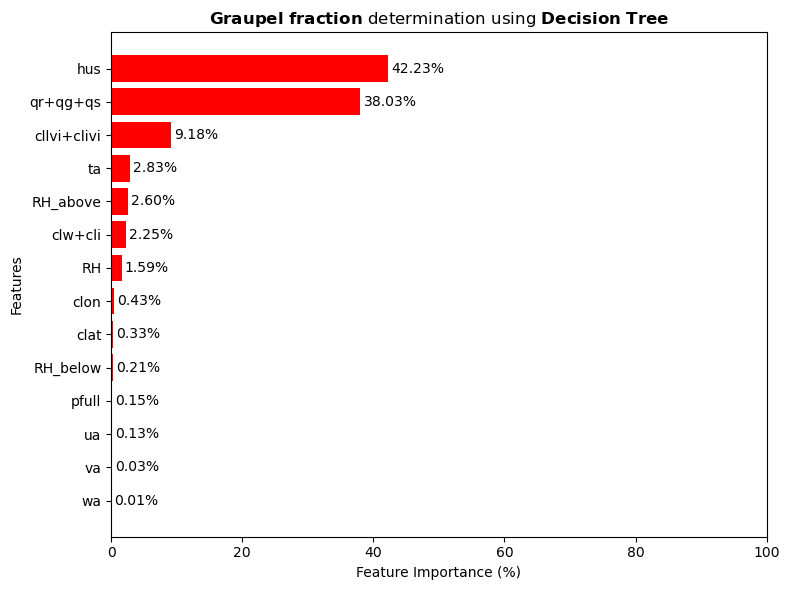

In [24]:
import matplotlib.pyplot as plt

# Your existing logic
importance = reg.feature_importances_
feature_scores = list(zip(feature_names, importance))
feature_scores.sort(key=lambda x: x[1], reverse=True)

# Convert to percentages
names = []
importances = []

for name, score in feature_scores:
    pct = score * 100
    names.append(name)
    importances.append(pct)
    print(f'{name}:{pct:.4f} %')

# ---- Bar plot ----
plt.figure(figsize=(8, 6))
bars = plt.barh(names, importances, color="red")

plt.xlabel("Feature Importance (%)")
plt.ylabel("Features")
plt.title(r"$\mathbf{Graupel\  fraction}$ determination using $\mathbf{Decision\ Tree}$")


# Highest importance at the top
plt.gca().invert_yaxis()

# Add percentage labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    plt.text(
        width + 0.5,   # small space after bar
        y,
        f"{width:.2f}%",
        va="center"
    )

# Set x-axis from 0 to 100
plt.xlim(0, 100)

plt.tight_layout()
plt.show()


In [ ]:
# best_ccp_alpha= best_.ccp_alpha
# best_ccp_alpha

Bagging

In [ ]:
#expt with min_sample_leaf = 50, etc. 

In [ ]:
# #for loop to see at what n_estimators the validation error converges

# X_train_sub, X_val, y_train_sub, y_val=train_test_split(X_train, y_train, test_size=0.2, random_state=1)

# prev_validation_r2_score=0 #Initialized arbitrarily to 0 to run the first tree in the for loop 
# diff=1 # difference between R2 scores of the previous and the current tree. Initialized arbitrarily to 1 to run the first tree in the for loop 
# upper_bound_n_trees=201
# x_axis= range(1,upper_bound_n_trees)
# threshold= 1E-7 ###1E-7
# train_sub_r2_scores=[]
# validation_r2_scores=[]
# for n_trees in x_axis:
        
#         # print("Diff= ", diff)
#         if(diff<threshold):
#                 print(f"Converged at {n_trees-1} trees")
#                 ideal_n_trees= n_trees-1
#                 break


#         #Bagging
#         model = RandomForestRegressor(n_jobs=-1, random_state=0, max_depth=best_depth, min_samples_leaf=best_min_samples_leaf ,n_estimators=n_trees, oob_score=True) #can set verbose=2 to see the steps 

#         ##Training
#         model.fit(X_train_sub, y_train_sub)

#         train_sub_r2= model.score(X_train_sub, y_train_sub)
#         validation_r2 = model.score(X_val, y_val)

#         train_sub_r2_scores.append(train_sub_r2)
#         validation_r2_scores.append(validation_r2)

#         diff= abs(validation_r2 - prev_validation_r2_score)
#         prev_validation_r2_score=validation_r2

# n_trees_for_which_max_r2 = x_axis[validation_r2_scores.index(max(validation_r2_scores))]


# print(f"Best number of trees (based on validation data): {n_trees_for_which_max_r2}")
# print(f"Best validation R² score: {max(validation_r2_scores)}")

# if(diff>=threshold):
#                 ideal_n_trees= upper_bound_n_trees-1

# plt.figure(figsize=(8,5))
# plt.plot(range(1, len(train_sub_r2_scores)+1 ), train_sub_r2_scores, marker='o', label='Training R2')
# plt.plot(range(1, len(validation_r2_scores)+1 ), validation_r2_scores, marker='s', label='Validation R2')
# plt.xlabel('Number of Trees')
# plt.ylabel('R2 Score')
# plt.title('R2 score vs number of trees')
# plt.legend()
# plt.grid(True)
# plt.show()


In [ ]:
#Bagging
ideal_n_trees=100
model = RandomForestRegressor(n_jobs=-1, random_state=0, max_depth=best_depth, n_estimators=ideal_n_trees, oob_score=True, min_samples_leaf=best_min_samples_leaf) #can set verbose=2 to see the steps 

##Training
training_start_time = time.time()
model.fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

##Prediction
prediction_start_time = time.time()
y_pred = model.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")
 

#Error Analysis on TEST data
#MSE_test
MSE_Test = np.mean((y_test - y_pred)**2)
print(f'MSE_Test: {MSE_Test}')

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
print(f'RMSE_TEST: {rmse_TEST}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_pred))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_pred)
print("R² score (sklearn):", r2_sklearn)

Training- Elapsed time: 0.6670 minutes
Prediction- Elapsed time: 0.0012 minutes
MSE_Test: 0.005312448758658379
RMSE_TEST: 0.07288654717201508
mae_TEST: 0.02620496192575838
R² score (sklearn): 0.9553854407662857


In [ ]:
#Bagging ft. importance in descending order
#Sort indices by importance
sorted_idx = np.argsort(model.feature_importances_)[::-1]

#print("\nAll features sorted by importance:")
for i in sorted_idx:
    pct=model.feature_importances_[i] * 100
    print(f"{feature_names[i]}: {pct:.4f} %")

ta: 45.8684 %
RH: 41.8325 %
qr+qg+qs: 6.5380 %
cllvi+clivi: 3.4501 %
hus: 0.6830 %
clw+cli: 0.5651 %
ua: 0.5453 %
clat: 0.1481 %
pfull: 0.1383 %
clon: 0.1191 %
va: 0.0658 %
wa: 0.0463 %


ta: 45.8684 %
RH: 41.8325 %
qr+qg+qs: 6.5380 %
cllvi+clivi: 3.4501 %
hus: 0.6830 %
clw+cli: 0.5651 %
ua: 0.5453 %
clat: 0.1481 %
pfull: 0.1383 %
clon: 0.1191 %
va: 0.0658 %
wa: 0.0463 %


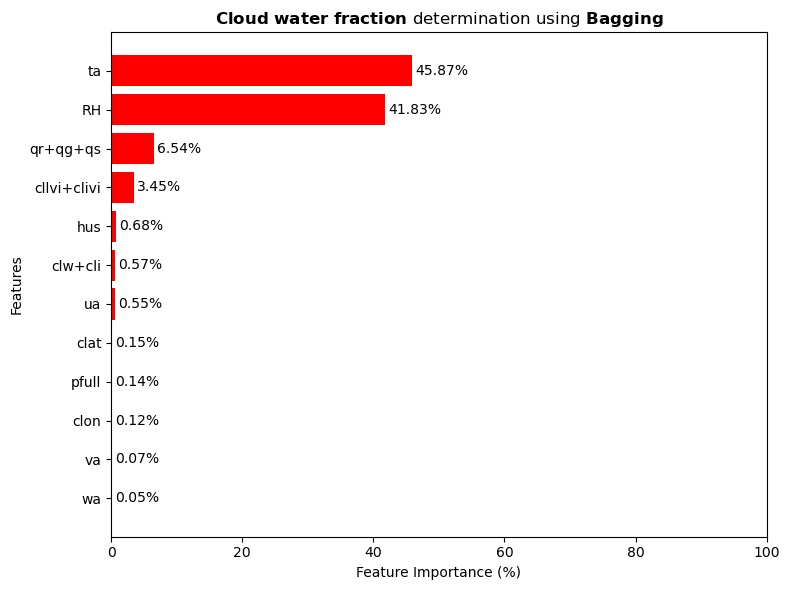

In [ ]:
sorted_idx = np.argsort(model.feature_importances_)[::-1]

names = []
importances = []

for i in sorted_idx:
    pct = model.feature_importances_[i] * 100
    names.append(feature_names[i])
    importances.append(pct)
    print(f"{feature_names[i]}: {pct:.4f} %")

# ---- Bar plot ----
plt.figure(figsize=(8, 6))
bars = plt.barh(names, importances, color="red")

plt.xlabel("Feature Importance (%)")
plt.ylabel("Features")
plt.title(r"$\mathbf{Graupel\  fraction}$ determination using $\mathbf{Bagging}$")

# Highest importance at the top
plt.gca().invert_yaxis()

# Add percentage labels at the end of bars
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    plt.text(
        width + 0.5,
        y,
        f"{width:.2f}%",
        va="center"
    )

# Set x-axis from 0 to 100
plt.xlim(0, 100)

plt.tight_layout()
plt.show()


In [ ]:
# # Bagging with CCP

# ideal_n_trees=100
# #I am using the best_ccp_alpha I got from a single Decision Tree using CV
# model = RandomForestRegressor(ccp_alpha=best_ccp_alpha, n_jobs=-1, random_state=0, max_depth=best_depth, n_estimators=ideal_n_trees, oob_score=True, min_samples_leaf=best_min_samples_leaf) #can set verbose=2 to see the steps 

# ##Training
# training_start_time = time.time()
# model.fit(X_train, y_train)
# training_end_time = time.time()
# training_elapsed_time = training_end_time - training_start_time
# print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

# ##Prediction
# prediction_start_time = time.time()
# y_pred = model.predict(X_test)
# prediction_end_time = time.time()
# prediction_elapsed_time = prediction_end_time - prediction_start_time
# print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")
 

# #Error Analysis on TEST data
# #MSE_test
# MSE_Test = np.mean((y_test - y_pred)**2)
# print(f'MSE_Test: {MSE_Test}')

# #rmse_test
# rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
# print(f'RMSE_TEST: {rmse_TEST}')

# #mae_TEST
# mae_TEST = np.mean(abs(y_test - y_pred))
# print(f'mae_TEST: {mae_TEST}')

# #R2_test_sklearn
# r2_sklearn = r2_score(y_test, y_pred)
# print("R² score (sklearn):", r2_sklearn)


In [ ]:
# #Bagging ft. importance in descending order
# #Sort indices by importance
# sorted_idx = np.argsort(model.feature_importances_)[::-1]

# #print("\nAll features sorted by importance:")
# for i in sorted_idx:
#     print(f"{feature_names[i]}: {model.feature_importances_[i]:.4f}")

Random Forest

#Bagging Code 2

Random Forest

In [ ]:
# #ideal num of trees for Random Forest
# #for loop to see at what n_estimators the validation error converges

# X_train_sub, X_val, y_train_sub, y_val=train_test_split(X_train, y_train, test_size=0.2, random_state=1)

# prev_validation_r2_score=0 #Initialized arbitrarily to 0 to run the first tree in the for loop 
# diff=1 # difference between R2 scores of the previous and the current tree. Initialized arbitrarily to 1 to run the first tree in the for loop 
# upper_bound_n_trees=201
# x_axis= range(1,upper_bound_n_trees)
# threshold= 1E-7 #1E-7
# train_sub_r2_scores=[]
# validation_r2_scores=[]
# for n_trees in x_axis:
        
#         # print("Diff= ", diff)
#         if(diff<threshold):
#                 print(f"Converged at {n_trees-1} trees")
#                 ideal_n_trees= n_trees-1
#                 break


#         #Bagging
#         model = RandomForestRegressor(n_jobs=-1, random_state=0, max_features=int(np.sqrt(X_train.shape[1])), max_depth=best_depth, min_samples_leaf=best_min_samples_leaf ,n_estimators=n_trees, oob_score=True) #can set verbose=2 to see the steps 

#         ##Training
#         model.fit(X_train_sub, y_train_sub)

#         train_sub_r2= model.score(X_train_sub, y_train_sub)
#         validation_r2 = model.score(X_val, y_val)

#         train_sub_r2_scores.append(train_sub_r2)
#         validation_r2_scores.append(validation_r2)

#         diff= abs(validation_r2 - prev_validation_r2_score)
#         prev_validation_r2_score=validation_r2

# n_trees_for_which_max_r2 = x_axis[validation_r2_scores.index(max(validation_r2_scores))]


# print(f"Best number of trees (based on validation data): {n_trees_for_which_max_r2}")
# print(f"Best validation R² score: {max(validation_r2_scores)}")

# if(diff>=threshold):
#                 ideal_n_trees= upper_bound_n_trees-1

# plt.figure(figsize=(8,5))
# plt.plot(range(1, len(train_sub_r2_scores)+1 ), train_sub_r2_scores, marker='o', label='Training R2')
# plt.plot(range(1, len(validation_r2_scores)+1 ), validation_r2_scores, marker='s', label='Validation R2')
# plt.xlabel('Number of Trees')
# plt.ylabel('R2 Score')
# plt.title('R2 score vs number of trees')
# plt.legend()
# plt.grid(True)
# plt.show()


In [ ]:
#Random Forest
##Training
ideal_n_trees=100

training_start_time = time.time()
RF_condensates = RandomForestRegressor(n_estimators=ideal_n_trees, max_features=int(np.sqrt(X_train.shape[1])), n_jobs=-1, random_state=0, max_depth=best_depth, min_samples_leaf=best_min_samples_leaf, oob_score=True).fit(X_train, y_train)
#RF_condensates = RandomForestRegressor(n_estimators=ideal_n_trees, max_features=int( np.floor(0.75 * X_train.shape[1])), n_jobs=-1, random_state=0, max_depth=best_depth, min_samples_leaf=best_min_samples_leaf, oob_score=True).fit(X_train, y_train)
# RF_condensates = RF(n_estimators=200, max_features=int(np.sqrt(X_train.shape[1])), n_jobs=-1, random_state=0, oob_score=True).fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

##Prediction
prediction_start_time = time.time()
y_hat_RF = RF_condensates.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

print("max: ", np.max(y_hat_RF))
print("min: ", np.min(y_hat_RF))

Training- Elapsed time: 0.2737 minutes
Prediction- Elapsed time: 0.0013 minutes
max:  0.9594674876913803
min:  0.0003953852885168638


In [ ]:
int( np.floor(0.75 * X_train.shape[1]))

9

In [ ]:
int(np.sqrt(X_train.shape[1]))

3

In [ ]:
RF_condensates

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,30
,min_weight_fraction_leaf,0.0
,max_features,3
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [ ]:
# List of depths for all trees
tree_depths = [estimator.tree_.max_depth for estimator in RF_condensates.estimators_]

# Average, min, and max depth across the forest
print("Average depth:", sum(tree_depths) / len(tree_depths))
print("Min depth:", min(tree_depths))
print("Max depth:", max(tree_depths))


Average depth: 10.0
Min depth: 10
Max depth: 10


In [ ]:
#Error Analysis on TEST data
#mse_Test
mse= np.mean((y_test- y_hat_RF)**2)
print('MSE: ', mse)

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_hat_RF)**2))
print(f'RMSE_TEST: {rmse_TEST}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_hat_RF))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_hat_RF)
print("R² score: ", r2_sklearn) 

MSE:  0.006264018858099974
RMSE_TEST: 0.07914555488528699
mae_TEST: 0.033062250863628906
R² score:  0.9473940449909616


ta: 30.3150 %
hus: 24.7721 %
RH: 13.4247 %
qr+qg+qs: 7.7540 %
pfull: 6.6090 %
clat: 5.5711 %
clw+cli: 4.7168 %
cllvi+clivi: 3.6577 %
ua: 1.5295 %
wa: 0.6397 %
va: 0.5612 %
clon: 0.4494 %


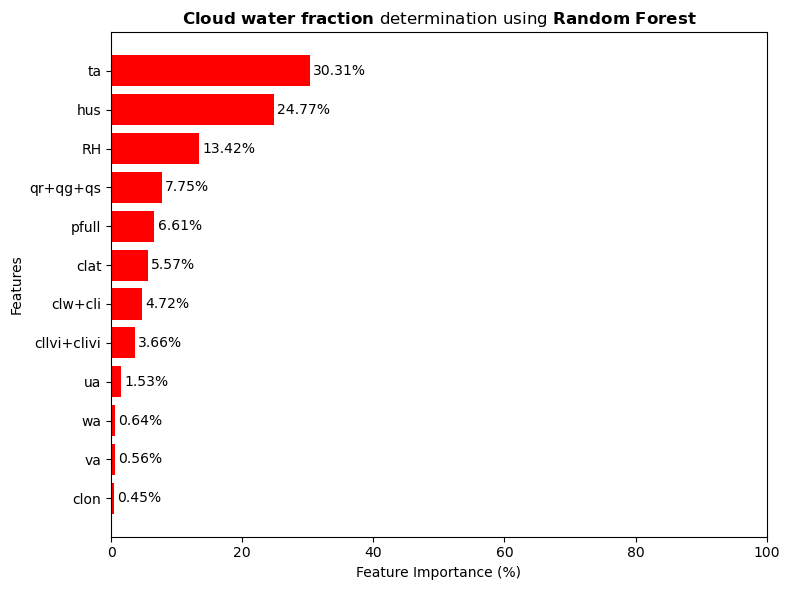

In [ ]:
importance = RF_condensates.feature_importances_

# Combine feature names and scores
feature_scores = list(zip(feature_names, importance))

# Sort by score in descending order
feature_scores.sort(key=lambda x: x[1], reverse=True)

# Convert to percentages
names = []
importances = []

for name, score in feature_scores:
    pct = score * 100
    names.append(name)
    importances.append(pct)
    print(f"{name}: {pct:.4f} %")

# ---- Bar plot ----
plt.figure(figsize=(8, 6))
bars = plt.barh(names, importances, color="red")

plt.xlabel("Feature Importance (%)")
plt.ylabel("Features")
plt.title(r"$\mathbf{Graupel\  fraction}$ determination using $\mathbf{Random\ Forest}$")

# Highest importance at the top
plt.gca().invert_yaxis()

# Add percentage labels at the end of the bars
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    plt.text(
        width + 0.5,
        y,
        f"{width:.2f}%",
        va="center"
    )

# Set x-axis range from 0 to 100
plt.xlim(0, 100)

plt.tight_layout()
plt.show()


In [ ]:
# #Random Forest with CCP

# ##Training
# ideal_n_trees=100

# training_start_time = time.time()
# RF_condensates = RandomForestRegressor(ccp_alpha= best_ccp_alpha, n_estimators=ideal_n_trees, max_features=int(np.sqrt(X_train.shape[1])), n_jobs=-1, random_state=0, max_depth=best_depth, min_samples_leaf=best_min_samples_leaf, oob_score=True).fit(X_train, y_train)
# #RF_condensates = RandomForestRegressor(n_estimators=ideal_n_trees, max_features=int( np.floor(0.75 * X_train.shape[1])), n_jobs=-1, random_state=0, max_depth=best_depth, min_samples_leaf=best_min_samples_leaf, oob_score=True).fit(X_train, y_train)
# # RF_condensates = RF(n_estimators=200, max_features=int(np.sqrt(X_train.shape[1])), n_jobs=-1, random_state=0, oob_score=True).fit(X_train, y_train)
# training_end_time = time.time()
# training_elapsed_time = training_end_time - training_start_time
# print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

# ##Prediction
# prediction_start_time = time.time()
# y_hat_RF = RF_condensates.predict(X_test)
# prediction_end_time = time.time()
# prediction_elapsed_time = prediction_end_time - prediction_start_time
# print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

# print("max: ", np.max(y_hat_RF))
# print("min: ", np.min(y_hat_RF))

# #Error Analysis on TEST data
# #mse_Test
# mse= np.mean((y_test- y_hat_RF)**2)
# print('MSE: ', mse)

# #rmse_test
# rmse_TEST = np.sqrt(np.mean((y_test - y_hat_RF)**2))
# print(f'RMSE_TEST: {rmse_TEST}')

# #mae_TEST
# mae_TEST = np.mean(abs(y_test - y_hat_RF))
# print(f'mae_TEST: {mae_TEST}')

# #R2_test_sklearn
# r2_sklearn = r2_score(y_test, y_hat_RF)
# print("R² score: ", r2_sklearn) #old value: 0.9922993421321149

In [ ]:
# #RF Ft. importance in descending order
# importance = RF_condensates.feature_importances_

# #Combine ft. names and scores
# feature_scores = list(zip(feature_names, importance))

# #Sort by score in descending order
# feature_scores.sort(key=lambda x: x[1], reverse=True)

# for name, score in feature_scores:
#     print(f'{name}:{score:.6f}')

XGBoost

In [ ]:
# #Method 1: Grid Search
# from sklearn.model_selection import GridSearchCV

# param_grid={
#     'n_estimators': [100, 200],
#     'max_depth': [5, 7, 10, 12],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'min_child_weight': [10, 30]
# }


# xgb_model= xgb.XGBRegressor()

# grid_search= GridSearchCV(xgb_model, param_grid, cv=5, scoring='r2')


# grid_search.fit(X_train, y_train)

# print("Best set of hyperparameters: ", grid_search.best_params_)
# print("Best score: ", grid_search.best_score_)


In [ ]:
# #n_estimators, eta/learning_rate, max_depth, min_child_weight?, max_bin (def=256)->increasing this number improves the optimality of splits at the cost of higher computation time.
# #Method 2: Random Search
# import scipy.stats as stats

# param_dist = {
#     'n_estimators': stats.randint(100, 201),
#     'max_depth': stats.randint(5,13),
#     'learning_rate': stats.uniform(0.01, 0.2),
#     'min_child_weight': stats.randint(10, 31)
#     }

# model = XGBRegressor()

# # Set up the random search with 4-fold cross validation
# random_cv = RandomizedSearchCV(random_state=1, estimator=model, param_distributions= param_dist, cv=5, n_iter=100, scoring='r2', n_jobs=-1, return_train_score= True)  #verbose=5

# random_cv.fit(X_train, y_train)

# print("Best set of hyperparameters: ", random_cv.best_params_)
# print("Best score: ", random_cv.best_score_)

In [ ]:
#random_cv.best_estimator_

In [25]:
# best_parameters= grid_search.best_params_

best_n_estimators=100 #best_parameters['n_estimators']
best_min_child_weight=30 #best_parameters['min_child_weight']
best_max_depth=10 #best_parameters['max_depth']
best_learning_rate=0.1 #best_parameters['learning_rate']

In [26]:
#XGBoost

# fit model
model = XGBRegressor(n_estimators=best_n_estimators, min_child_weight= best_min_child_weight, max_depth=best_max_depth, learning_rate=best_learning_rate, n_jobs=-1, random_state=0) #verbosity=3 (optional)

##Training
training_start_time = time.time()
model.fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

##Prediction
prediction_start_time = time.time()
y_pred = model.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

Training- Elapsed time: 0.9377 minutes
Prediction- Elapsed time: 0.0089 minutes


In [27]:
print("max: ", np.max(y_pred))
print("min: ", np.min(y_pred))

max:  1.2106106
min:  -0.28206113


In [ ]:
# count=0
# for i in y_pred:
#     if i>1 or i<0:
#         # print(i)
#         count+=1
# print("incorrect count = ", count)
# print("incorrect count percent = ", 100*count/len(y_pred))

In [28]:
y_pred = np.clip(y_pred, 0, 1)

In [29]:
y_test=y_test.ravel()
y_pred=y_pred.ravel()

In [30]:
#Error Analysis on TEST data
#mse
mse= np.mean((y_test- y_pred)**2)
print('MSE_Test: ', mse)

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
print(f'RMSE_TEST: {rmse_TEST}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_pred))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_pred)
print("R² score: ", r2_sklearn)

MSE_Test:  0.011968645
RMSE_TEST: 0.10940130054950714
mae_TEST: 0.05644554644823074
R² score:  0.866702139377594


In [31]:
#xgb feature importance
importance = model.feature_importances_

#Combine feature names and scores
feature_scores = list(zip(feature_names, importance))

#Sort by score in descending order
feature_scores.sort(key=lambda x: x[1], reverse=True)

for name, score in feature_scores:
    print(f'{name}:{score:.6f}')

hus:0.448644
qr+qg+qs:0.195265
cllvi+clivi:0.077591
RH_above:0.076040
RH:0.058397
ta:0.053907
clw+cli:0.030202
pfull:0.011162
RH_below:0.011162
clon:0.010295
clat:0.010010
ua:0.006888
va:0.005487
wa:0.004948


hus: 44.8644 %
qr+qg+qs: 19.5265 %
cllvi+clivi: 7.7591 %
RH_above: 7.6040 %
RH: 5.8397 %
ta: 5.3907 %
clw+cli: 3.0202 %
pfull: 1.1162 %
RH_below: 1.1162 %
clon: 1.0295 %
clat: 1.0010 %
ua: 0.6888 %
va: 0.5487 %
wa: 0.4948 %


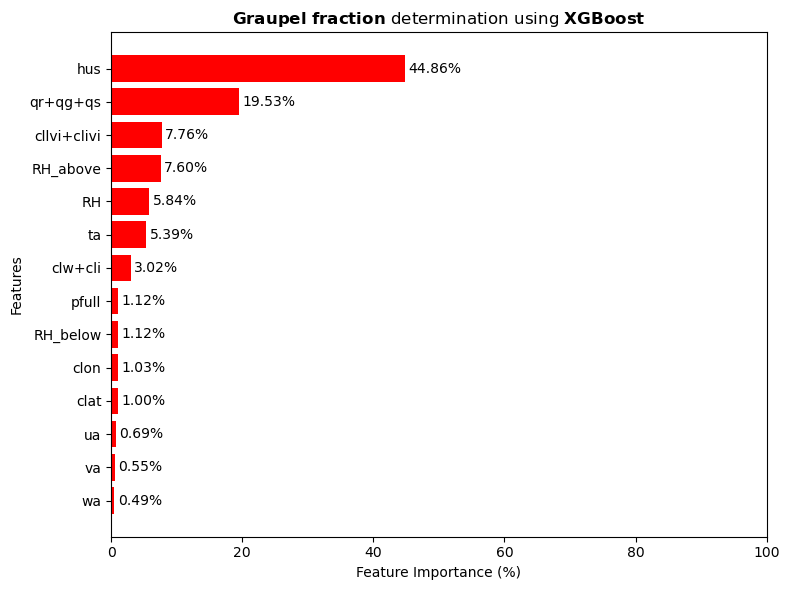

In [32]:
import matplotlib.pyplot as plt

# ---- Your existing logic ----
importance = model.feature_importances_

# Combine feature names and scores
feature_scores = list(zip(feature_names, importance))

# Sort by score in descending order
feature_scores.sort(key=lambda x: x[1], reverse=True)

# Convert to percentages
names = []
importances = []

for name, score in feature_scores:
    pct = score * 100
    names.append(name)
    importances.append(pct)
    print(f"{name}: {pct:.4f} %")

# ---- Bar plot ----
plt.figure(figsize=(8, 6))
bars = plt.barh(names, importances, color="red")

plt.xlabel("Feature Importance (%)")
plt.ylabel("Features")
plt.title(r"$\mathbf{Graupel\  fraction}$ determination using $\mathbf{XGBoost}$")

# Highest importance at the top
plt.gca().invert_yaxis()

# Add percentage labels
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    plt.text(
        width + 0.5,
        y,
        f"{width:.2f}%",
        va="center"
    )

# Set x-axis range
plt.xlim(0, 100)

plt.tight_layout()
plt.show()


In [ ]:
# plt.figure(figsize=(8,6))
# sns.scatterplot(x=y_test.flatten(), y=y_pred.flatten(), alpha=0.7)
# plt.xlabel("Actual Values")
# plt.ylabel("Predicted Values")
# plt.title("Actual vs Predicted Values (XGB)")
# # Add a perfect prediction line
# plt.plot([y_test.min(), y_test.max()],
#          [y_test.min(), y_test.max()],
#          color='red', lw=2)
# plt.show()


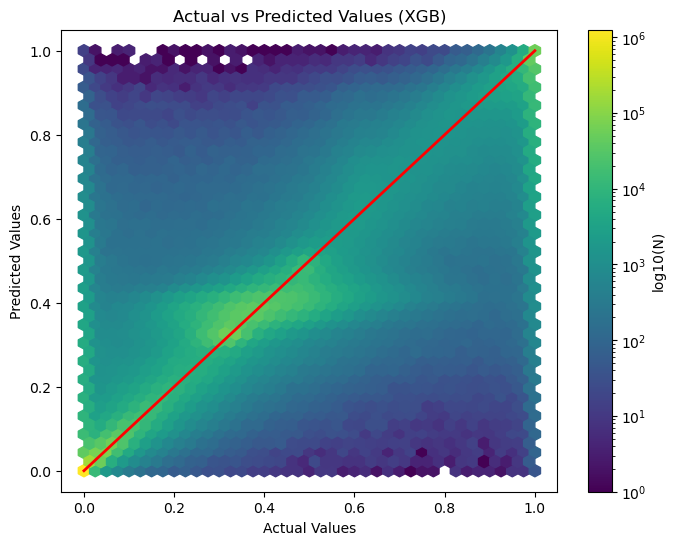

In [33]:
plt.figure(figsize=(8,6))
plt.hexbin(
    y_test.flatten(), 
    y_pred.flatten(), 
    gridsize=40,  # smaller → finer grid
    cmap='viridis', 
    bins='log'  # logarithmic scaling helps emphasize dense areas
)
plt.colorbar(label='log10(N)')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red', lw=2
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (XGB)")
plt.show()


BART

In [ ]:
#BART

# bart_condensates = BART(random_state=0, burnin=100, ndraw=15)
# bart_condensates.fit(X_train, y_train)

In [ ]:
# yhat_test = bart_condensates.predict(X_test.astype(np.float32))

# yhat_test = np.clip(yhat_test, 0, 1)
# np.mean((y_test- yhat_test)**2)

In [ ]:
# var_inclusion = pd.Series(bart_condensates.variable_inclusion_.mean(0),
#  index=D.columns)
# var_inclusion

In [ ]:
overall_end_time = time.time()

totalElapsedTime=overall_end_time - overall_start_time
print(f"The Total Elapsed Time is: {totalElapsedTime/60:.4f} minutes")

The Total Elapsed Time is: 3.0771 minutes
